<a href="https://colab.research.google.com/github/leofigueredo2008-beep/CHECKPOINT2_SERS_1CCPG/blob/main/Checkpoint2_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa

Use o notebook de apoio para consultar duas APIs públicas e gerar os arquivos aneel_classificacao_orange.csv e meteo_regressao_orange.csv. Em seguida, desenvolva duas tarefas independentes em Python: uma de classificação e outra de regressão. Treine e compare três algoritmos diferentes em cada tarefa. O notebook fornece apenas a conexão às APIs e a preparação dos CSVs: bibliotecas, modelos, análises e resultados de ML devem ser acrescentados por você.

As consultas públicas escolhidas não exigem token. Caso um serviço passe a exigir credenciais, nunca as publique no GitHub.

#Entrega

Envie somente o link para um repositório público no GitHub. Ele deve conter:

Um README.md com objetivo, origem e período dos dados, instruções de execução e conclusões das duas tarefas.
O notebook .ipynb completo, executável na ordem, com seus imports, análise, treinamento e comparação dos seis modelos (três por tarefa), métricas, gráficos e interpretação em texto.
Os dois arquivos CSV gerados, ou instruções completas e verificadas para reproduzi-los a partir das APIs.
Não publique senhas ou tokens. As tabelas de resultados devem identificar claramente os três algoritmos de cada tarefa e a mesma configuração de avaliação usada na comparação.

##Preparação do Ambiente



In [5]:
#Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

#Machine Learning
#Algoritmos do sklean para classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Algoritmos do sklearn para regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#Separação de dados de treino e teste
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test

#Padronização de modelos
from sklearn.preprocessing import StandardScaler

#Métricas de classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#Métricas de regressão
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Tarefa 1 — Classificação da fonte renovável
Fonte: SIGA — ANEEL. Cada linha do CSV representa um empreendimento de geração no Brasil. A coluna fonte reúne Solar (UFV), Eólica (EOL) e Hidráulica (UHE, PCH, CGH). O cadastro inclui empreendimentos em diferentes fases; os dados não medem energia gerada.

Atributo no CSV	Origem na API	Descrição	Papel
potencia_kw	MdaPotenciaOutorgadaKw	Potência outorgada em quilowatts; não representa energia produzida	Entrada
latitude	NumCoordNEmpreendimento	Latitude aproximada, em graus decimais	Entrada
longitude	NumCoordEEmpreendimento	Longitude aproximada, em graus decimais	Entrada
fonte	SigTipoGeracao	Categoria da fonte, agrupada em três classes	Alvo
Seu trabalho: explore a quantidade de linhas, valores ausentes, distribuição das classes e características das entradas. Defina X e y; separe treino/teste de forma estratificada (sugestão: 80%/20%) e fixe a semente. Treine três classificadores distintos nas mesmas divisões e compare Accuracy, Precision, Recall, F1 e matriz de confusão. Informe se usou média macro, weighted ou outra para métricas multiclasses. Interprete as classes mais confundidas e as limitações de prever a fonte apenas por potência e localização. Faça padronização dentro do treino quando o algoritmo exigir; não use como entrada nome, código CEG, sigla ou descrição que entregue a resposta.

##Carregar os Dados Ex.1

In [ ]:
dados1 = pd.read_csv("https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv")

dados1.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


##Análise Exploratória Ex.1

In [ ]:
dados1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
#Somente estatísticas de atributos categóricos
dados1.describe(include="object")

,fonte
count,3876
unique,3
top,Hidráulica
freq,1476


In [ ]:
#Somente estatísticas de atributos numéricos
dados1.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [ ]:
#Printando detalhes
print("A API da ANEEL possui:")

print(f"- {dados1.shape[0]} registros, com {dados1.shape[1]} atributos")

print(f"- {dados1.isnull().sum().sum()} registros em branco")

print(f"- Distribuição das classes:")
print(f"  Hidráulica: {dados1['fonte'].value_counts()['Hidráulica']}")
print(f"  Solar: {dados1['fonte'].value_counts()['Solar']}")
print(f"  Eólica: {dados1['fonte'].value_counts()['Eólica']}")

print(f"")

A API da ANEEL possui:
- 3876 registros, com 4 atributos
- 0 registros em branco
- Distribuição das classes:
  Hidráulica: 1476
  Solar: 1200
  Eólica: 1200



##Instanciando Modelos Ex.1


In [ ]:
#Instanciando os modelos de classificacao
modelo1_LR = LogisticRegression()
modelo1_KNN = KNeighborsClassifier()
modelo1_RF = RandomForestClassifier()

In [ ]:
#Definindo y (target) e X (features)
y = dados1['fonte']
display(y.head())

X = dados1.drop('fonte', axis=1)
display(X.head())

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


In [ ]:
#Separando dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=27)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Treinando Modelos Ex.1

In [ ]:
#Logistic Regression
modelo1_LR.fit(X_train, y_train)

#KNN
modelo1_KNN.fit(X_train, y_train)

#Random Forest
modelo1_RF.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y1_predict_LR = modelo1_LR.predict(X_test)
y1_predict_KNN = modelo1_KNN.predict(X_test)
y1_predict_RF = modelo1_RF.predict(X_test)

##Métricas Ex.1

In [ ]:
#Métricas de Logistic Regression
accuracy1_LR = 100 * accuracy_score(y_test, y1_predict_LR)
precision1_LR = 100 * precision_score(y_test, y1_predict_LR, average='macro')
recall1_LR = 100 * recall_score(y_test, y1_predict_LR, average='macro')
f1_LR = 100 * f1_score(y_test, y1_predict_LR, average='macro')
confusion_matrix1_LR = confusion_matrix(y_test, y1_predict_LR)

print(f"Logistic Regression")
print(f"  Accuracy: {accuracy1_LR:.2f}%")
print(f"  Precision: {precision1_LR:.2f}%")
print(f"  Recall: {recall1_LR:.2f}%")
print(f"  F1: {f1_LR:.2f}%")

Logistic Regression
  Accuracy: 81.57%
  Precision: 81.86%
  Recall: 81.06%
  F1: 80.97%


In [ ]:
#Métricas de KNeighborsClassifier
accuracy1_KNN = 100 * accuracy_score(y_test, y1_predict_KNN)
precision1_KNN = 100 * precision_score(y_test, y1_predict_KNN, average='macro')
recall1_KNN = 100 * recall_score(y_test, y1_predict_KNN, average='macro')
f1_KNN = 100 * f1_score(y_test, y1_predict_KNN, average='macro')
confusion_matrix1_KNN = confusion_matrix(y_test, y1_predict_KNN)

print(f"KNeighbors Classifier")
print(f"  Accuracy: {accuracy1_KNN:.2f}%")
print(f"  Precision: {precision1_KNN:.2f}%")
print(f"  Recall: {recall1_KNN:.2f}%")
print(f"  F1: {f1_KNN:.2f}%")

KNeighbors Classifier
  Accuracy: 95.88%
  Precision: 95.84%
  Recall: 95.79%
  F1: 95.81%


In [ ]:
#Random Forest Classifier
accuracy1_RF = 100 * accuracy_score(y_test, y1_predict_RF)
precision1_RF = 100 * precision_score(y_test, y1_predict_RF, average='macro')
recall1_RF = 100 * recall_score(y_test, y1_predict_RF, average='macro')
f1_RF = 100 * f1_score(y_test, y1_predict_RF, average='macro')
confusion_matrix1_RF = confusion_matrix(y_test, y1_predict_RF)

print(f"Random Forest Classifier")
print(f"  Accuracy: {accuracy1_RF:.2f}%")
print(f"  Precision: {precision1_RF:.2f}%")
print(f"  Recall: {recall1_RF:.2f}%")
print(f"  F1: {f1_RF:.2f}%")

Random Forest Classifier
  Accuracy: 97.55%
  Precision: 97.58%
  Recall: 97.44%
  F1: 97.50%


Para Precision, Recall e F1 foi utilizada a média macro (average='macro'), que calcula a métrica individualmente para cada uma das três classes e depois realiza a média simples entre elas, atribuindo o mesmo peso a Solar, Eólica e Hidráulica.

##Tabela Comparativa de Modelos Ex.1

In [ ]:
data = {
    'Modelo': ['Logistic Regression', 'KNeighbors Classifier', 'Random Forest Classifier'],
    'Accuracy (%)': [accuracy1_LR, accuracy1_KNN, accuracy1_RF],
    'Precision (%)': [precision1_LR, precision1_KNN, precision1_RF],
    'Recall (%)': [recall1_LR, recall1_KNN, recall1_RF],
    'F1 Score (%)': [f1_LR, f1_KNN, f1_RF]
}

df_metrics = pd.DataFrame(data)
display(df_metrics.round(2))

,Modelo,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,81.57,81.86,81.06,80.97
1,KNeighbors Classifier,95.88,95.84,95.79,95.81
2,Random Forest Classifier,97.55,97.58,97.44,97.50


## Visualização das Matrizes de Confusão Ex.1

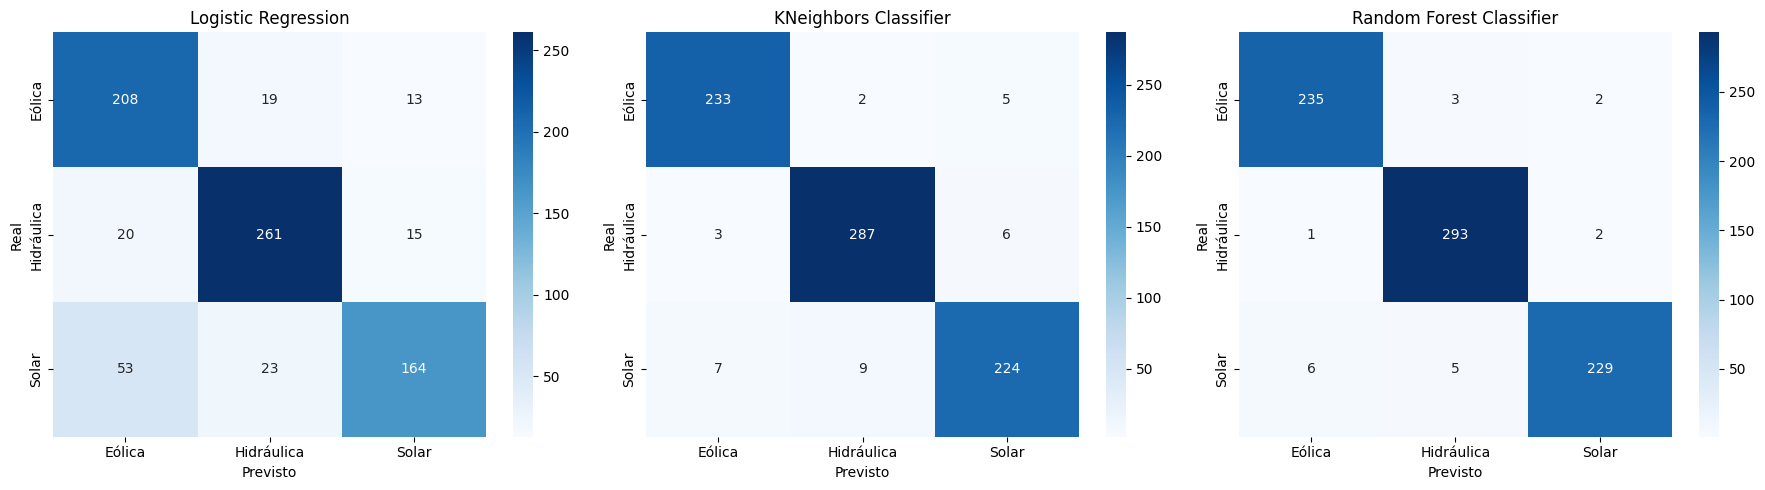

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression Confusion Matrix
sb.heatmap(confusion_matrix1_LR, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Eólica', 'Hidráulica', 'Solar'], yticklabels=['Eólica', 'Hidráulica', 'Solar'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# KNN Confusion Matrix
sb.heatmap(confusion_matrix1_KNN, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Eólica', 'Hidráulica', 'Solar'], yticklabels=['Eólica', 'Hidráulica', 'Solar'])
axes[1].set_title('KNeighbors Classifier')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

# Random Forest Confusion Matrix
sb.heatmap(confusion_matrix1_RF, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Eólica', 'Hidráulica', 'Solar'], yticklabels=['Eólica', 'Hidráulica', 'Solar'])
axes[2].set_title('Random Forest Classifier')
axes[2].set_xlabel('Previsto')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

##Interpretação das classes

As matrizes de confusão mostram que a Logistic Regression apresenta maior dificuldade para distinguir a classe Solar das demais. O principal caso de confusão ocorre entre Solar e Eólica: 53 empreendimentos realmente solares foram classificados como eólicos. Também houve 23 casos de Solar classificados como Hidráulica. Entre Eólica e Hidráulica, as confusões foram menores, com 19 casos de Eólica classificados como Hidráulica e 20 de Hidráulica classificados como Eólica.

No KNN, as confusões diminuem consideravelmente. A maior quantidade ocorre novamente na classe Solar, com 7 casos classificados como Eólica e 9 como Hidráulica. As classes Eólica e Hidráulica apresentam apenas 2 e 3 casos de confusão entre si.

No Random Forest, a maior parte das observações está na diagonal principal da matriz, indicando classificações corretas. As confusões são pequenas em todas as classes: 6 casos de Solar foram classificados como Eólica e 5 como Hidráulica, enquanto Eólica e Hidráulica apresentaram apenas 3 e 1 casos de confusão, respectivamente.

Portanto, considerando as matrizes, a distinção entre Solar e Eólica é a principal fonte de erro, especialmente na Logistic Regression. A redução dessas confusões nos modelos KNN e Random Forest também é consistente com os resultados das métricas apresentadas anteriormente.

##Limitações da classificação

A classificação utiliza apenas três variáveis de entrada: potência outorgada, latitude e longitude. Embora essas características apresentem padrões suficientes para permitir a classificação dos empreendimentos presentes no conjunto de dados, elas não representam diretamente todas as características físicas e operacionais que determinam a escolha ou o funcionamento de uma fonte de geração.

A localização pode estar associada indiretamente à disponibilidade de determinados recursos naturais e à distribuição regional dos empreendimentos, enquanto a potência pode apresentar padrões diferentes entre as tecnologias. Entretanto, essas variáveis não informam diretamente características como disponibilidade de recurso solar ou eólico, vazão dos rios, características do terreno, tecnologia utilizada ou outros fatores de projeto.

Além disso, os dados da ANEEL representam empreendimentos de geração cadastrados e a variável fonte corresponde à categoria registrada no cadastro. Portanto, o modelo está aprendendo padrões existentes nesse conjunto de dados, e não uma relação física universal capaz de determinar a fonte renovável de qualquer empreendimento apenas a partir de sua potência e localização.

Dessa forma, os resultados devem ser interpretados dentro do contexto e das características do dataset utilizado. A inclusão de outras variáveis relevantes poderia fornecer informações adicionais para a classificação.

#Tarefa 2

Fonte: API histórica Open-Meteo. Dados horários estimados para Petrolina (PE), coordenadas aproximadas −9,39, −40,50, de 01/04/2025 a 30/06/2025, no fuso America/Recife. Cada linha do CSV é uma hora local entre 7h e 17h. Os valores históricos são derivados de modelos/reanálise, não de um painel fotovoltaico.

Seu trabalho: explore as variáveis e os dados ausentes; apresente ao menos uma visualização e defina X e y. Use as primeiras 80% das horas para treino e as últimas 20% para teste, preservando a ordem temporal. Treine três regressores diferentes usando a mesma divisão. Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos. Explique o papel da hora do dia e por que estimar radiação não equivale a prever a geração elétrica. Não inclua radiacao_w_m2 ou uma transformação direta dela em X.

##Carregar Dados Ex.2

In [6]:
dados2 = pd.read_csv("https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/meteo_regressao_orange.csv")

dados2.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


##Análise Exploratória Ex.2

In [7]:
dados2.columns

Index(['data_hora', 'temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh',
       'hora', 'radiacao_w_m2'],
      dtype='object')

In [8]:
dados2.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


In [9]:
valores_ausentes = dados2.isnull().sum().sum()
print(f"O dataset possuí {valores_ausentes} valores ausentes")

O dataset possuí 0 valores ausentes


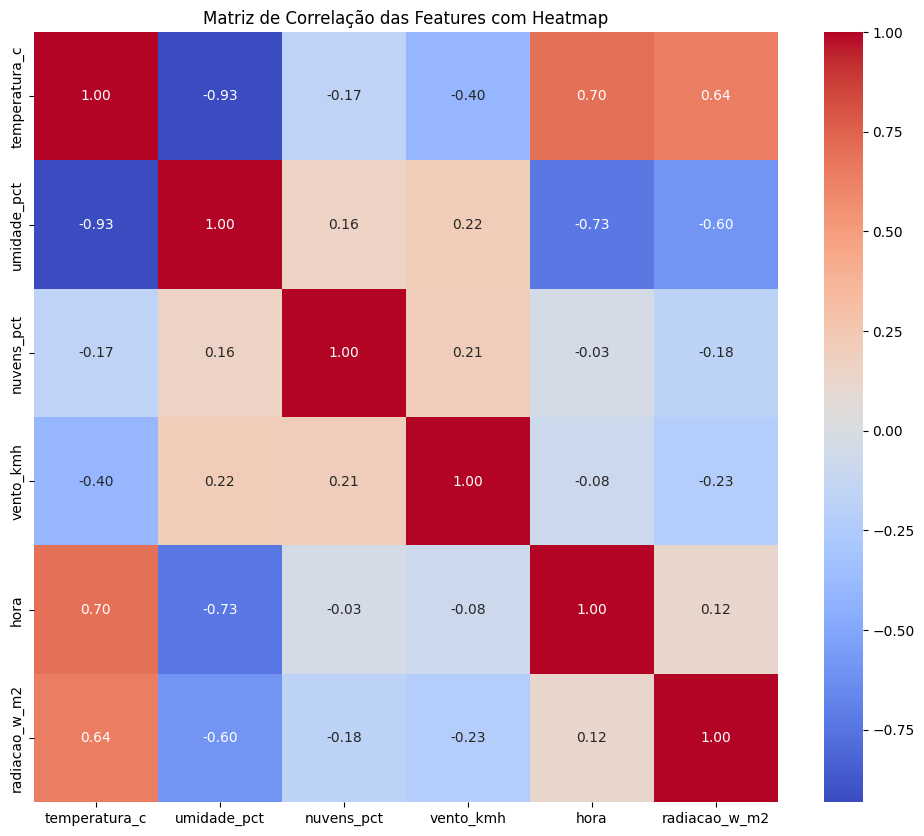


Correlações com a variável alvo "radiacao_w_m2":

radiacao_w_m2    1.000000
temperatura_c    0.642733
hora             0.120143
nuvens_pct      -0.180196
vento_kmh       -0.229388
umidade_pct     -0.596183
Name: radiacao_w_m2, dtype: float64


In [11]:
# Calcular a matriz de correlação
correlation_matrix = dados2.corr(numeric_only=True)

# Display do heatmap
plt.figure(figsize=(12, 10))
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Features com Heatmap')
plt.show()

# Retornar correlações da variável 'radiacao_w_m2' e ordenar elas
radiacao_correlations = correlation_matrix['radiacao_w_m2'].sort_values(ascending=False)
print('\nCorrelações com a variável alvo "radiacao_w_m2":\n')
print(radiacao_correlations)

A matriz revela a correlação linear entre as features e a coluna target "radiacao_w_m2". sendo que "temperature_c" é a que possui a maior, enqaunto a "umidade_pct" possui a menor.

In [12]:
'''Mantenha as linhas em ordem de data_hora: use aproximadamente 80% das primeiras horas para treino e as 20% finais para teste.
Evite embaralhar as horas. Ajuste transformações apenas com o treino.'''

dados2 = dados2.sort_values(by='data_hora')

X = dados2.drop(['data_hora', 'radiacao_w_m2'], axis=1)
y = dados2['radiacao_w_m2']

split_index = int(len(dados2) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

Tamanho do conjunto de treino: 800 amostras
Tamanho do conjunto de teste: 201 amostras


##Treinando Modelos Ex.2

In [13]:
# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

modelo_LR = LinearRegression()
modelo_RFR = RandomForestRegressor()
modelo_DTR = DecisionTreeRegressor()

O modelo de Regressão Linear é adequado quando existe uma relação aproximadamente linear entre as features e a variável target, que pode ser representada por uma função afim. Testamos esse algoritmo partindo da hipótese de que a relação entre as entradas e a saída do dataset poderia apresentar esse comportamento.

Já a Árvore de Decisão para Regressão consegue capturar relações não necessariamente lineares entre as features e a variável target. Internamente, ela divide recursivamente os dados do conjunto de treinamento com base em condições sobre as features, formando regiões nas quais são realizadas as previsões. Em uma tarefa de regressão, a previsão de uma folha é normalmente baseada na média dos valores da variável target dos exemplos que chegaram até ela. Entretanto, uma árvore muito profunda pode se ajustar excessivamente aos dados de treinamento, causando overfitting. Testamos esse algoritmo partindo da hipótese de que a relação entre as entradas e a saída do dataset poderia apresentar padrões não lineares.

Por fim, a Random Forest para Regressão é composta por várias árvores de decisão treinadas sobre diferentes amostras dos dados e subconjuntos aleatórios de features. O modelo combina as previsões das árvores, normalmente calculando sua média para problemas de regressão. Essa combinação tende a tornar o modelo mais robusto e reduzir a variância em relação a uma árvore de decisão individual, diminuindo a suscetibilidade ao overfitting. Testamos esse modelo partindo da mesma hipótese de existência de relações não lineares utilizada para a árvore de decisão.

Dessa forma, os três modelos foram testados para comparar diferentes formas de representar a relação entre as features e a variável target: uma abordagem linear, uma árvore individual capaz de modelar relações não lineares e um conjunto de árvores que busca obter maior robustez por meio da combinação de múltiplos modelos.

In [14]:
modelo_LR.fit(X_train, y_train)
modelo_RFR.fit(X_train, y_train)
modelo_DTR.fit(X_train, y_train)

DecisionTreeRegressor()

In [15]:
'''Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos de pelo menos um modelo.'''

yLR_predict = modelo_LR.predict(X_test)
yRFR_predict = modelo_RFR.predict(X_test)
yDTR_predict = modelo_DTR.predict(X_test)

In [16]:
print("Regressão Linear")
print(f"MAE: {mean_absolute_error(y_test, yLR_predict):.2f}")
print(f"MSE: {mean_squared_error(y_test, yLR_predict):.2f}")
print(f"R²: {r2_score(y_test, yLR_predict):.2f}")

print("\nRandom Forest Regressor")
print(f"MAE: {mean_absolute_error(y_test, yRFR_predict):.2f}")
print(f"MSE: {mean_squared_error(y_test, yRFR_predict):.2f}")
print(f"R²: {r2_score(y_test, yRFR_predict):.2f}")

print("\nDecision Tree Regressor")
print(f"MAE: {mean_absolute_error(y_test, yDTR_predict):.2f}")
print(f"MSE: {mean_squared_error(y_test, yDTR_predict):.2f}")
print(f"R²: {r2_score(y_test, yDTR_predict):.2f}")

Regressão Linear
MAE: 145.20
MSE: 30034.20
R²: 0.36

Random Forest Regressor
MAE: 67.76
MSE: 7335.99
R²: 0.84

Decision Tree Regressor
MAE: 84.72
MSE: 13235.91
R²: 0.72


## Tabela Comparativa dos Modelos de Regressão Ex.2

In [17]:
metrics = {
    'Modelo': ['Linear Regression', 'Random Forest Regressor', 'Decision Tree Regressor'],
    'MAE': [
        mean_absolute_error(y_test, yLR_predict),
        mean_absolute_error(y_test, yRFR_predict),
        mean_absolute_error(y_test, yDTR_predict)
    ],
    'MSE': [
        mean_squared_error(y_test, yLR_predict),
        mean_squared_error(y_test, yRFR_predict),
        mean_squared_error(y_test, yDTR_predict)
    ],
    'R2': [
        r2_score(y_test, yLR_predict),
        r2_score(y_test, yRFR_predict),
        r2_score(y_test, yDTR_predict)
    ]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics.round(2))

,Modelo,MAE,MSE,R2
0,Linear Regression,145.20,30034.20,0.36
1,Random Forest Regressor,67.76,7335.99,0.84
2,Decision Tree Regressor,84.72,13235.91,0.72


## Gráfico de Valores Reais vs. Previstos e Resíduos (Random Forest Regressor)

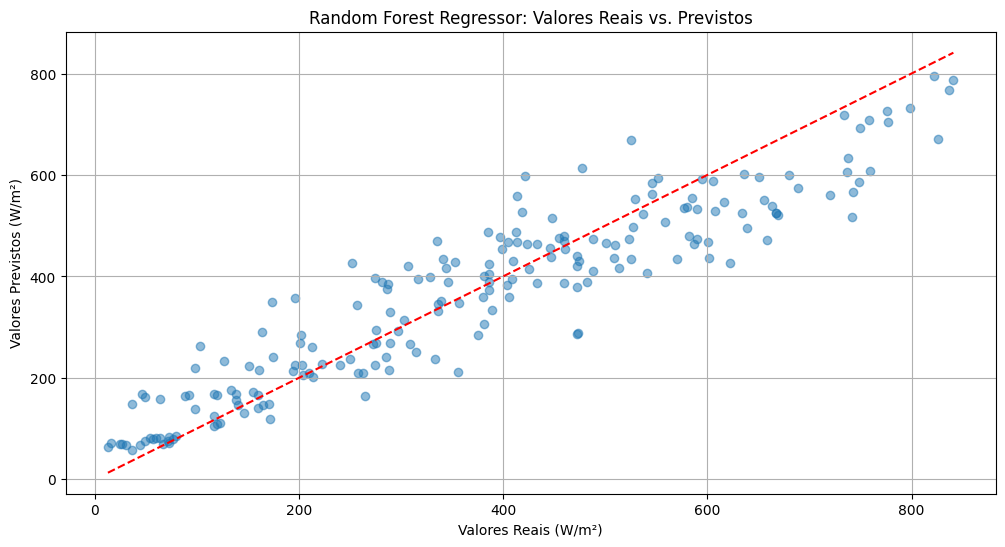

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, yRFR_predict, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reais (W/m²)')
plt.ylabel('Valores Previstos (W/m²)')
plt.title('Random Forest Regressor: Valores Reais vs. Previstos')
plt.grid(True)
plt.show()

### Interpretação dos Erros e Discussão sobre o Peso da 'Hora'

O Random Forest Regressor apresentou o melhor desempenho entre os três modelos, com o menor MAE e MSE e o maior R². Isso indica que, no conjunto de teste, suas previsões foram mais próximas dos valores reais de radiação e apresentaram menor magnitude de erro.

- MAE (Mean Absolute Error): representa a magnitude média dos erros. Um MAE de 64,73 W/m² para o Random Forest significa que, em média, suas previsões ficaram cerca de 64,73 W/m² distantes dos valores reais.
- MSE (Mean Squared Error): calcula a média dos erros ao quadrado, penalizando erros maiores de forma mais intensa. O MSE de 6.880,01 (W/m²)² indica que o Random Forest apresentou erros quadráticos menores que os outros modelos.
- R² (Coefficient of Determination): indica a proporção da variabilidade da variável-alvo explicada pelo modelo. Um R² de 0,85 significa que, no conjunto de teste, aproximadamente 85% da variabilidade observada na radiação foi explicada pelas variáveis utilizadas no modelo.

#### O peso da 'hora'

A correlação entre hora e radiacao_w_m2 foi de apenas 0,12, indicando uma correlação linear fraca. Entretanto, isso não significa que a variável seja irrelevante.

A radiação solar apresenta um comportamento tipicamente não linear ao longo do dia: tende a ser baixa durante a noite, aumenta durante a manhã, atinge valores maiores próximo ao período central do dia e diminui novamente durante a tarde. Portanto, uma correlação de Pearson baixa não necessariamente representa ausência de relação.

Modelos baseados em árvores, como a Random Forest, conseguem capturar relações não lineares desse tipo. Assim, a baixa correlação linear da hora não deve ser interpretada isoladamente como evidência de que essa variável não possui importância para a previsão.

### Por que a estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico

A estimativa da radiação solar é um insumo importante para estimar a geração fotovoltaica, mas radiação e energia elétrica produzida são grandezas diferentes. A radiação em W/m² representa a irradiância solar, enquanto a energia elétrica produzida é normalmente medida em Wh ou kWh.

Além da radiação disponível, a geração depende de características e condições do sistema, como:

Potência e eficiência dos módulos: determinam quanto da radiação incidente pode ser convertida em eletricidade.
Orientação e inclinação: afetam a quantidade de radiação efetivamente recebida pelos módulos.
Temperatura dos módulos: temperaturas elevadas geralmente reduzem a eficiência elétrica dos módulos.
Sombreamento e sujeira: reduzem a radiação efetivamente aproveitada pelo sistema.
Perdas elétricas: inversor, cabeamento e outros componentes introduzem perdas durante a conversão e transmissão da energia.

Portanto, a radiação prevista pelo modelo representa a disponibilidade do recurso solar, enquanto a energia produzida depende de como um sistema fotovoltaico específico converte esse recurso em eletricidade.